In [1]:
import numpy as np

# Van der Pol

In [60]:
import sympy as smp

## Symbolic solution

In [69]:
x1, x2, mu, w, t, alp, F= smp.symbols(r'x_1 x_2 \mu \omega t \alpha \mathcal{F}')

# sin = (w*t) - (w*t)**3/(3*2) #+ (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

w = 1.2
alp = 0


dx1 = x2
dx2 = -x1 + mu*x2*(1-x1**2) + alp*smp.sin(w*t)
dt = 1

### Jacobian about origin

In [70]:
# Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2),smp.diff(dx1,t)],
#                   [smp.diff(dx2,x1),smp.diff(dx2,x2),smp.diff(dx2,t)],
#                   [smp.diff(dt,x1),smp.diff(dt,x2),smp.diff(dt,t)]])


Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2)],
                  [smp.diff(dx2,x1),smp.diff(dx2,x2)]])

Jac

Matrix([
[                 0,                1],
[-2*\mu*x_1*x_2 - 1, \mu*(1 - x_1**2)]])

In [71]:
J0 = Jac.subs([[x1,0],[x2,0],[mu,1]])
J0

Matrix([
[ 0, 1],
[-1, 1]])

In [72]:
J0.eigenvects()

[(1/2 - sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 + sqrt(3)*I/2],
   [                1]])]),
 (1/2 + sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 - sqrt(3)*I/2],
   [                1]])])]

In [65]:
J0.eigenvals()

{0: 1, 1/2 - sqrt(3)*I/2: 1, 1/2 + sqrt(3)*I/2: 1}

### Transform

In [73]:
ev1 = J0.eigenvects()[0][2][0]
ev2 = J0.eigenvects()[1][2][0]
# ev3 = J0.eigenvects()[2][2][0]
ev1

Matrix([
[1/2 + sqrt(3)*I/2],
[                1]])

In [74]:
# P = smp.Matrix([[ev1.T],
#                [ev2.T],
#                [ev3.T]]).T

P = smp.Matrix([[ev1.T],
               [ev2.T]]).T
P

Matrix([
[1/2 + sqrt(3)*I/2, 1/2 - sqrt(3)*I/2],
[                1,                 1]])

In [75]:
# c, s, u = smp.symbols('c s u')

# P_inv = P.inv()
# csu = smp.Matrix([c,s,u])
# xyt_dot = smp.Matrix([dx1,dx2,dt])


s, u = smp.symbols('s u')

P_inv = P.inv()
su = smp.Matrix([s,u])
xy_dot = smp.Matrix([dx1,dx2])

In [76]:
# trans = P@csu
trans = P@su
trans

Matrix([
[s*(1/2 + sqrt(3)*I/2) + u*(1/2 - sqrt(3)*I/2)],
[                                        s + u]])

In [77]:
su_dot = P_inv@xy_dot
su_dot

Matrix([
[x_2*(sqrt(3) - I)/(sqrt(3) + 3*I) - (\mu*x_2*(1 - x_1**2) - x_1)/(-3/2 + sqrt(3)*I/2)],
[                   sqrt(3)*I*x_2/3 + (1/2 - sqrt(3)*I/6)*(\mu*x_2*(1 - x_1**2) - x_1)]])

In [79]:
su_dot = su_dot.subs([[x1,trans[0]],
                       [x2,trans[1]]])

### Manifold

In [81]:
# dc = csu_dot[0].expand()
ds =  su_dot[0].expand()
du = su_dot[1].expand()

In [88]:
# A = dc.coeff(c,1).coeff(s,0).coeff(u,0).coeff(alp,0)
A = ds.coeff(s,1).coeff(u,0).coeff(mu,0)
A

sqrt(3)/(sqrt(3) + 3*I) + sqrt(3)*I/(-3 + sqrt(3)*I) + 1/(-3 + sqrt(3)*I) - I/(sqrt(3) + 3*I)

In [89]:
g1 = ds - A*s
g1

sqrt(3)*I*\mu*s**3/(-3 + sqrt(3)*I) - \mu*s**3/(-3 + sqrt(3)*I) + 3*\mu*s**2*u/(-3 + sqrt(3)*I) + sqrt(3)*I*\mu*s**2*u/(-3 + sqrt(3)*I) + 3*\mu*s*u**2/(-3 + sqrt(3)*I) - sqrt(3)*I*\mu*s*u**2/(-3 + sqrt(3)*I) - \mu*s/(-3/2 + sqrt(3)*I/2) - \mu*u**3/(-3 + sqrt(3)*I) - sqrt(3)*I*\mu*u**3/(-3 + sqrt(3)*I) - \mu*u/(-3/2 + sqrt(3)*I/2) + sqrt(3)*s/(sqrt(3) + 3*I) + sqrt(3)*I*s/(-3 + sqrt(3)*I) + s/(-3 + sqrt(3)*I) - I*s/(sqrt(3) + 3*I) - s*(sqrt(3)/(sqrt(3) + 3*I) + sqrt(3)*I/(-3 + sqrt(3)*I) + 1/(-3 + sqrt(3)*I) - I/(sqrt(3) + 3*I)) + sqrt(3)*u/(sqrt(3) + 3*I) + u/(-3 + sqrt(3)*I) - I*u/(sqrt(3) + 3*I) - sqrt(3)*I*u/(-3 + sqrt(3)*I)

In [90]:
# b1 = ds.coeff(c,0).coeff(s,1).coeff(u,0).coeff(alp,0)
# b2 = du.coeff(c,0).coeff(s,0).coeff(u,1).coeff(alp,0)

# B = smp.Matrix([[b1,0],
#                 [0,b2]])
B = du.coeff(s,0).coeff(u,1).coeff(mu,0)
B

2*sqrt(3)*I/3

In [91]:
# g2_1 = ds - b1*s
# g2_2 = du - b2*u
# g2 = smp.Matrix([g2_1,g2_2])

g2 = du - B*u

g2

-sqrt(3)*I*\mu*s**3/3 - \mu*s**2*u - \mu*s*u**2/2 + sqrt(3)*I*\mu*s*u**2/2 + \mu*s/2 - sqrt(3)*I*\mu*s/6 + \mu*u**3/2 + sqrt(3)*I*\mu*u**3/6 + \mu*u/2 - sqrt(3)*I*\mu*u/6 - s/2 + sqrt(3)*I*s/6

In [101]:
k1, k2, k3, b1, b2, b3 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3 \beta_1 \beta_2 \beta_3')

h1 = k1*s**2 + k2*s*mu + k3*mu**2
# h2 = b1*c**2 + b2*c*alp + b3*alp**2

H = h1#smp.Matrix([h1,h2])
Dh = smp.diff(H,s)

In [102]:
N = Dh*(A*s + g1) - B*H - g2
N = N.subs(u,H).expand()
N

-2*\kappa_1**4*\mu*s**7/(-3 + sqrt(3)*I) - 2*sqrt(3)*I*\kappa_1**4*\mu*s**7/(-3 + sqrt(3)*I) - 7*\kappa_1**3*\kappa_2*\mu**2*s**6/(-3 + sqrt(3)*I) - 7*sqrt(3)*I*\kappa_1**3*\kappa_2*\mu**2*s**6/(-3 + sqrt(3)*I) - 6*\kappa_1**3*\kappa_3*\mu**3*s**5/(-3 + sqrt(3)*I) - 6*sqrt(3)*I*\kappa_1**3*\kappa_3*\mu**3*s**5/(-3 + sqrt(3)*I) - \kappa_1**3*\mu*s**6/2 + 6*\kappa_1**3*\mu*s**6/(-3 + sqrt(3)*I) - sqrt(3)*I*\kappa_1**3*\mu*s**6/6 - 2*sqrt(3)*I*\kappa_1**3*\mu*s**6/(-3 + sqrt(3)*I) - 9*\kappa_1**2*\kappa_2**2*\mu**3*s**5/(-3 + sqrt(3)*I) - 9*sqrt(3)*I*\kappa_1**2*\kappa_2**2*\mu**3*s**5/(-3 + sqrt(3)*I) - 15*\kappa_1**2*\kappa_2*\kappa_3*\mu**4*s**4/(-3 + sqrt(3)*I) - 15*sqrt(3)*I*\kappa_1**2*\kappa_2*\kappa_3*\mu**4*s**4/(-3 + sqrt(3)*I) - 3*\kappa_1**2*\kappa_2*\mu**2*s**5/2 + 15*\kappa_1**2*\kappa_2*\mu**2*s**5/(-3 + sqrt(3)*I) - sqrt(3)*I*\kappa_1**2*\kappa_2*\mu**2*s**5/2 - 5*sqrt(3)*I*\kappa_1**2*\kappa_2*\mu**2*s**5/(-3 + sqrt(3)*I) - 6*\kappa_1**2*\kappa_3**2*\mu**5*s**3/(-3 + sqrt

In [103]:
N1 = N
# N2 = N[1]

In [104]:
N1_c_pow2   = N1.coeff(s,2).coeff(mu,0)
N1_c_pow1   = N1.coeff(s,1).coeff(mu,0)
N1_c_alp    = N1.coeff(s,1).coeff(mu,1)
N1_alp_pow1 = N1.coeff(s,0).coeff(mu,1)
N1_alp_pow2 = N1.coeff(s,0).coeff(mu,2)

# N2_c_pow2   = N2.coeff(c,2).coeff(alp,0)
# N2_c_pow1   = N2.coeff(c,1).coeff(alp,0)
# N2_c_alp    = N2.coeff(c,1).coeff(alp,1)
# N2_alp_pow1 = N2.coeff(c,0).coeff(alp,1)
# N2_alp_pow2 = N2.coeff(c,0).coeff(alp,2)

In [105]:
N1_c_pow1

1/2 - sqrt(3)*I/6

In [106]:
N1_alp_pow1

0

In [117]:
k2_sub = smp.solve(N1_alp_pow1,k2)[0]
b2_sub = smp.solve(N2_alp_pow1,b2)[0]

In [106]:
N1_c_pow2.subs([[b1,0],[k1,0]])

0

In [118]:
N1_c_alp = N1_c_alp.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N1_c_alp

-\omega/2 - sqrt(3)*I*\omega/6

In [119]:
N1_alp_pow2 = N1_alp_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N1_alp_pow2

-\beta_3*\mu/2 - sqrt(3)*I*\beta_3*\mu/6 + \beta_3/2 + sqrt(3)*I*\beta_3/6 - \kappa_3*\mu/2 - sqrt(3)*I*\kappa_3*\mu/6 + 2*sqrt(3)*I*\kappa_3/3

In [120]:
N2_c_pow2 = N2_c_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_c_pow2

0

In [121]:
N2_c_alp = N2_c_alp.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_c_alp

-\omega/2 + sqrt(3)*I*\omega/6

In [131]:
N2_alp_pow2 = N2_alp_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_alp_pow2

-\beta_3*\mu/2 + sqrt(3)*I*\beta_3*\mu/6 - \beta_3*\mu*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(2*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) + sqrt(3)*I*\beta_3*\mu*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(6*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) - 2*sqrt(3)*I*\beta_3/3 + \beta_3*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(2*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) - sqrt(3)*I*\beta_3*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(6*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3)))

In [132]:
smp.solve([N1_alp_pow2,N2_alp_pow2],[k3,b3])

{\beta_3: 0, \kappa_3: 0}

In [133]:
smp.solve([N1_c_alp,N2_c_alp],[w])

{\omega: 0}

In [44]:
N2.subs([[k1,0],
        [k2,0],
        [k3,0]])

-1

In [159]:
dx1_f = smp.lambdify([x1,x2,t,mu,alp,w],dx1)
dx2_f = smp.lambdify([x1,x2,t,mu,alp,w],dx2)

In [160]:
x1v = np.linspace(-10,10,20)/2
x2v = np.linspace(-10,10,20)/2

x1G, x2G = np.meshgrid(x1v,x2v)

In [183]:
mu_val = 1
w_val = 1.2
a_val = 0
F_val = np.linspace(0,1,25)
t_val = np.linspace(0,10*np.pi,1000)

## Numerical solution

In [26]:
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# from ipywidgets import interact

In [4]:
clr = ['cornflowerblue',
      'gold',
      'tomato',
      'dimgray']

Eigenvalue pair

$$\frac{\mu}{2} \pm \frac{\sqrt{(\mu - 2)*(\mu + 2)}}{2}$$

When $\mu=1$

$$\frac{1}{2} \pm \frac{\sqrt{3}}{2}\mathcal{i}$$

In [ ]:
   
#     def comp_poincar(self):
#         x,y = self.soln[0]
#         t = self.soln[1]
#         diff = np.diff(x**2)
#         pos = np.where(diff>=0)[0]

#         idx = pos

#         gap = np.where(np.diff(idx)>1)[0]
#         idx = idx[gap+1]

#         y_map = y[idx]

#         pos = np.where(y_map>0)[0]

#         idx = idx[pos]
#         x_map = x[idx]
#         y_map = y[idx]
#         t_map = t[idx]

#         t_map = self.drive(t_map)/self.Af
        
#         self.poinSec = [t_map,y_map,x_map]
        
#         return self.poinSec
    
    def comp_poincar(self):
        """
        Detect crossings of x1 = 0 with x2 > 0
        using linear interpolation between samples.
        """
        x1,x2 = self.soln[0]

        poincare_x1 = []
        poincare_x2 = []

        for i in range(len(x1) - 1):
            # Check for sign change in x1 (zero crossing)
            if x1[i] * x1[i+1] < 0:
                # Linear interpolation to find crossing time
                alpha = -x1[i] / (x1[i+1] - x1[i])  # fraction between i and i+1
                x1_interp = x1[i] + alpha * (x1[i+1] - x1[i])  # ≈ 0
                x2_interp = x2[i] + alpha * (x2[i+1] - x2[i])

                # Only keep positive x2 crossings
                if x2_interp > 0:
                    poincare_x1.append(x1_interp)
                    poincare_x2.append(x2_interp)

        self.poinSec =  np.array([[poincare_x1], [poincare_x2]])
        
        
#     def plt_poincar(self):
#         if self.poinSec==None:
#             t,y,x = self.comp_poincar()
#         else:
#             t,y,x = self.poinSec
        
#         plt.scatter(t,y)
#         plt.grid()

    def plt_poincar(self):
        x, y = self.soln[0]
        t = self.soln[1]
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Full phase portrait
        axes[0].plot(x, y, 'b-', alpha=0.3, lw=0.5)
        axes[0].axvline(0, color='gray', linestyle='--', lw=0.8, label='x1=0 section')
        axes[0].set_xlabel('x1')
        axes[0].set_ylabel('x2')
        axes[0].set_title('Phase Portrait')
        axes[0].legend()
        
        
        px1,px2 = self.poinSec

        # Poincaré map
        axes[1].scatter(px1, px2, s=3, c='red', alpha=0.7)
        axes[1].set_xlabel('x1 (≈ 0)')
        axes[1].set_ylabel('x2')
        axes[1].set_title(f'Poincaré Map (x1=0, x2>0)\n{len(px2)} crossings')

        plt.tight_layout()

In [123]:
class vanDerPol:
    
    clr = ['cornflowerblue',
      'gold',
      'tomato',
      'dimgray']
    
    def __init__(self, mu, force):
        self.mu = mu
        self.force = force
        self.clr = clr
        self.soln = None
        self.T = None
        self.limC = None
        self.poinSec = None

    def dif_Eq(self,X,t):
        x1, x2 = X

        dx1 = x2
        dx2 = self.mu*x2*(1-x1**2)-x1 + self.force(t) #self.Af*np.sin(self.wf*t)

        return [dx1,dx2]

    

    def simulate(self, x0, t):
        def event(t, X):
            return X[0]           # triggers when x1 = 0
        event.direction = 1       # only negative→positive crossings (or -1 for the other)
        event.terminal = False
        
        sol = solve_ivp(
            lambda t, X: self.dif_Eq(X, t),
            [t[0], t[-1]], x0,
            t_eval=t, events=event, dense_output=True
        )
        self.soln = [sol.y, sol.t]
        # Event hits stored in sol.t_events[0], sol.y_events[0]
        t_cross = sol.t_events[0]
        y_cross = sol.y_events[0][:, 1]   # x2 at each crossing
        
        mask = y_cross > 0
        self.poinSec = (t_cross[mask], y_cross[mask])




    def get_limCycle(self,plot =False):
        x, y = self.soln[0]
        t = self.soln[1]
        
        dx = np.diff(x)
        idx = np.where(dx<=0)[0]
        jump = np.where(np.diff(idx)>1)[0]
        idx = idx[jump+1]
        theta0 = idx[-3]
        thetaf = idx[-2]
        self.T = t[thetaf] - t[theta0]
        self.limC = [x[theta0:thetaf],y[theta0:thetaf]]

        if plot ==True:
            plt.plot(self.limC[0],self.limC[1])
            plt.grid()
            plt.title(f'Limit Cycle, with period: {np.round(self.T,3)}')

        
    def plt_sim(self):
        x, y = self.soln[0]
        t = self.soln[1]
            
        fig = plt.figure(figsize=(14,6))
        
        gs = gridspec.GridSpec(1,4)
        
        p1 = fig.add_subplot(gs[:3])
        p2 = fig.add_subplot(gs[3:])
        
        
        p1.plot(t,x,color=self.clr[0],label=r'$\dot x_1$')
        p1.plot(t,y,color=self.clr[1],label=r'$\dot x_2$')
        p1.plot(t,self.force(t),color=self.clr[2],label=r'$F(t)$')
        p1.grid()

        y_min = np.min([x,y])
        y_max = np.max([x,y])
        p1.set_ylim([y_min,y_max])

        p1.legend()
        
        p2.plot(x,y)
        p2.grid()

        
    # def plt_poincare(self):
    #     x, y = self.soln[0]
    #     t = self.soln[1]
    #     t_p, y_p = self.poinSec
        
    #     plt.plot(t, y, color=self.clr[0], alpha=0.5, label=r'$x_2(t)$')
    #     plt.scatter(t_p, y_p, color=self.clr[2], zorder=5, label='Poincaré section')
    #     plt.xlabel('t'); plt.legend(); plt.grid()

    def plt_poincare(self, T=None):
        t_p, y_p = self.poinSec
        
        # Use provided period, limit cycle period, or raw time
        # period = T or self.T
        # t_mod = t_p % period if period is not None else t_p

        t_mod = self.force(t_p)
        
        plt.scatter(t_mod/np.max(t_mod), y_p, color=self.clr[2], s=10, zorder=5, label='Poincaré section')
        # plt.xlabel(r'$t \bmod T$' if period else r'$t$')
        plt.ylabel(r'$x_2$')
        plt.legend()
        plt.grid()


        

### Test case

In [140]:
def force(t):
    A = 0.3
    w =20
    return A*np.sin(w*t)# + A*np.sin(np.pi*t)

vdp_test = vanDerPol(mu = 1,force = force)

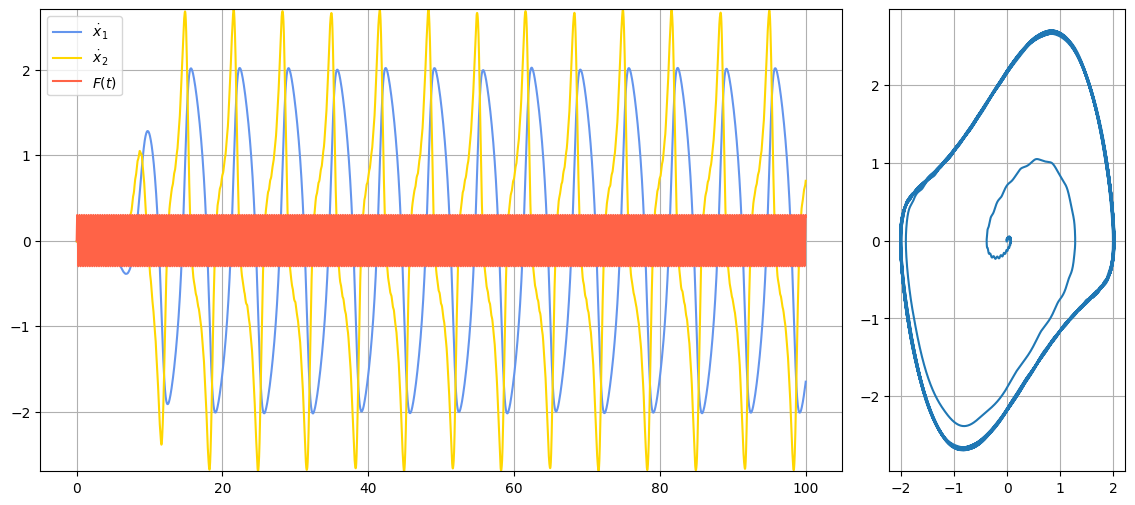

In [141]:
t = np.linspace(0,100,100000)
x0 = [-0.01,-0.01]

vdp_test.simulate(x0,t)
vdp_test.plt_sim()

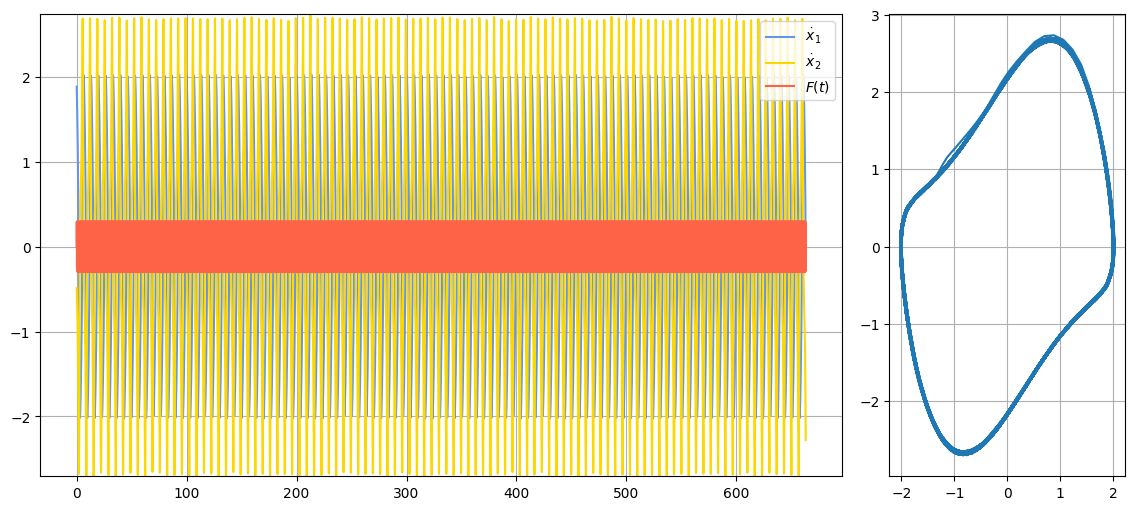

In [144]:
vdp_test.get_limCycle()
t = np.linspace(0,100*vdp_test.T,10000)
x,y = vdp_test.soln[0]
x0 = [x[-1],y[-1]]

vdp_test.simulate(x0,t)
vdp_test.plt_sim()

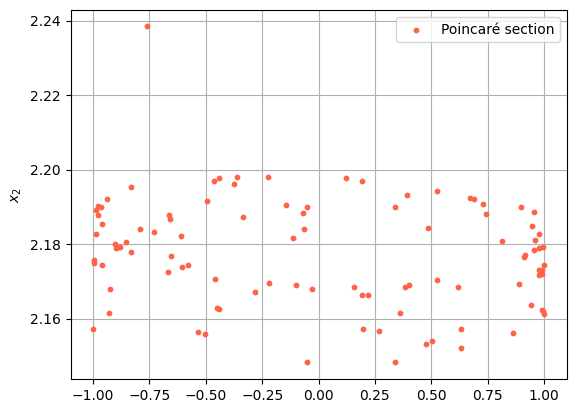

In [145]:
vdp_test.plt_poincare()

In [105]:
1.2/0.9

1.3333333333333333

### No Forcing

In [47]:
vdp_A0 = vanDerPol(1,0,0)

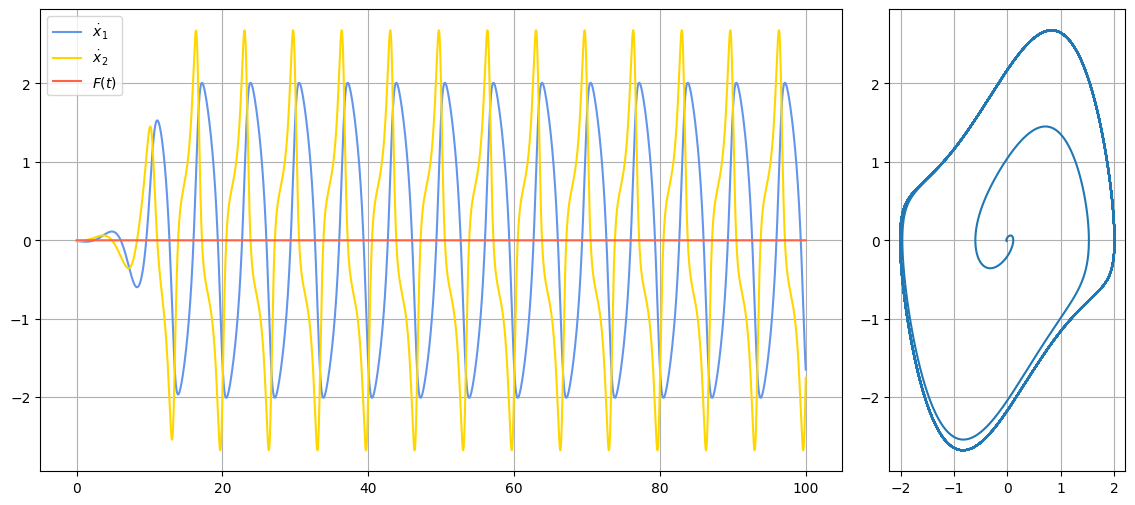

In [48]:
t = np.linspace(0,100,100000)
x0 = [-0.01,-0.01]
vdp_A0.simulate(x0,t)
vdp_A0.plt_sim()

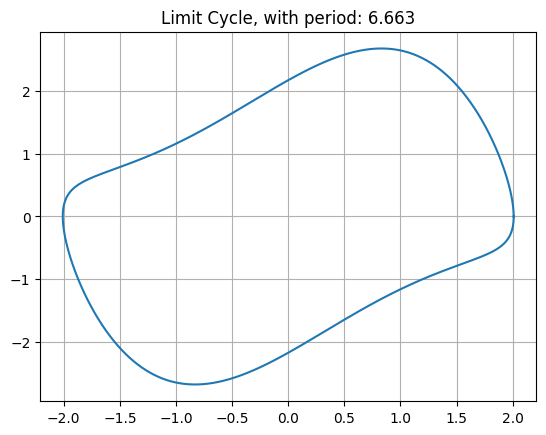

In [33]:
vdp_A0.get_limCycle(plot=True)

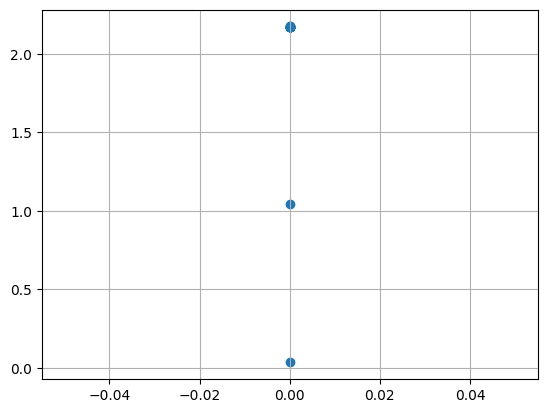

In [34]:
vdp_A0.plt_poincar()

### Small Forcing

In [41]:
vdp_A03 = vanDerPol(mu = 1,
                    Af = 0.3,
                    wf = 1.2)

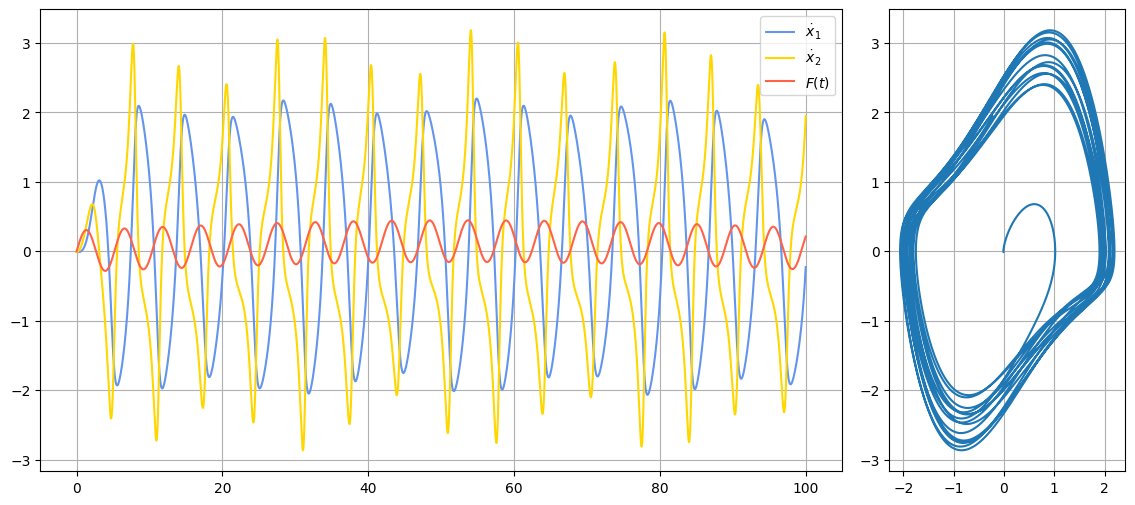

In [42]:
t = np.linspace(0,100,100000)
x0 = [-0.01,-0.01]

vdp_A03.simulate(x0,t)
vdp_A03.plt_sim()

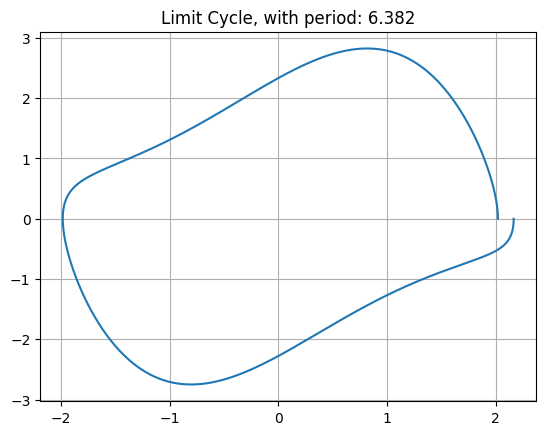

In [43]:
vdp_A03.get_limCycle(plot=True)

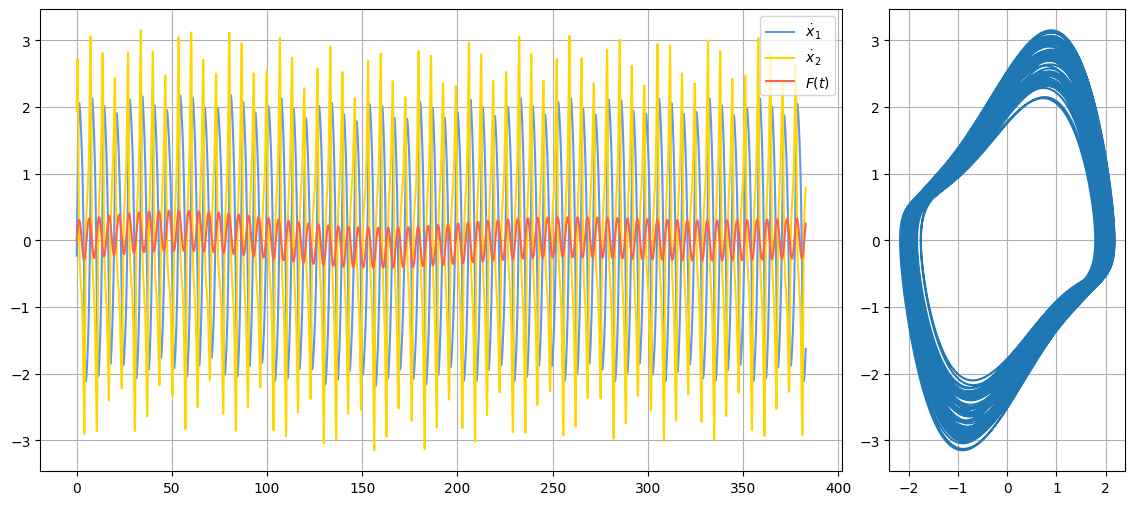

In [44]:
t = np.linspace(0,60*vdp_A03.T,100000)
x,y = vdp_A03.soln[0]
x0 = [x[-1],y[-1]]

vdp_A03.simulate(x0,t)
vdp_A03.plt_sim()

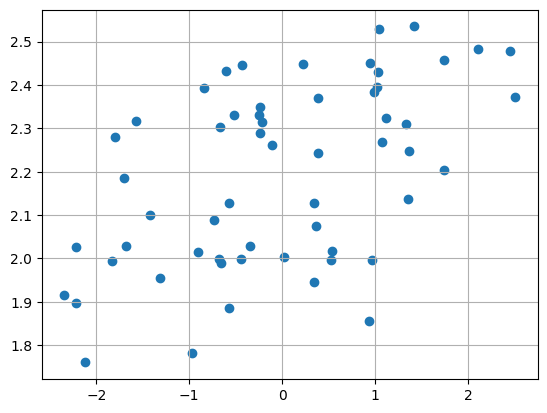

In [45]:
vdp_A03.plt_poincar()

### Adjoint